In [2]:
import sklearn

In [3]:
import numpy as np
import matplotlib.pyplot as plt

### Let us simulate firing rates from two stimulus conditions.

### Suppose we record from 40 neurons over 200 trials. Some neurons fire more strongly for stimulus 1.

In [4]:
rng = np.random.default_rng(42)

n_trials = 200
n_neurons = 40

# Labels: 0 = stimulus A, 1 = stimulus B
y = np.repeat([0, 1], n_trials // 2)

# Baseline firing rates
X = rng.normal(5, 1, size=(n_trials, n_neurons))

X[y == 1, :10] += 1.5

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 40)
y shape: (200,)


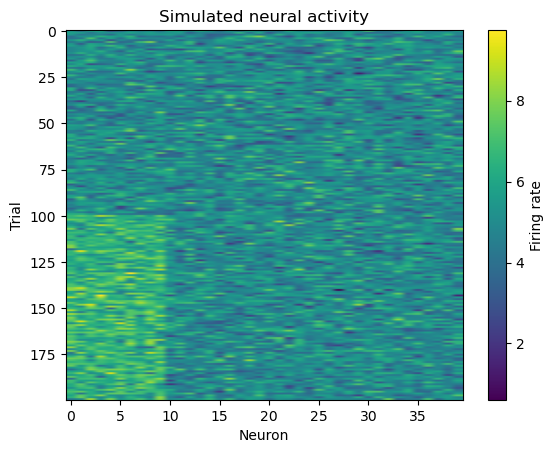

In [9]:
## visualise the data

plt.imshow(X, aspect="auto", cmap="viridis")
plt.xlabel("Neuron")
plt.ylabel("Trial")
plt.title("Simulated neural activity")
plt.colorbar(label="Firing rate")
plt.show()

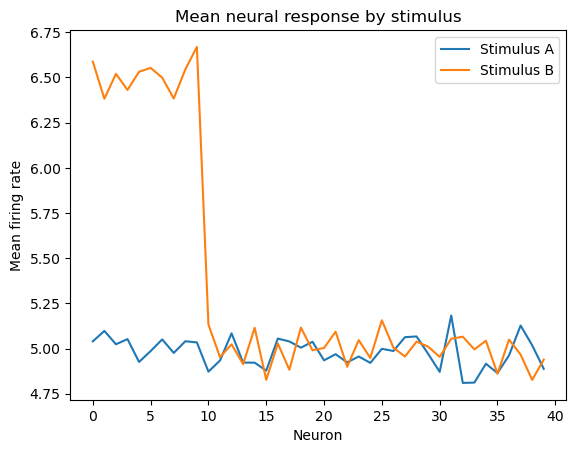

In [5]:
## compare avereage responses

mean_A = X[y == 0].mean(axis=0)
mean_B = X[y == 1].mean(axis=0)

plt.plot(mean_A, label="Stimulus A")
plt.plot(mean_B, label="Stimulus B")
plt.xlabel("Neuron")
plt.ylabel("Mean firing rate")
plt.title("Mean neural response by stimulus")
plt.legend()
plt.show()

### classification using logistic regression

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Split the data into train and test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=43,
    stratify=y
)

## Training data: used to fit the model
## Testing data: used to evaluate the model on unseen trials
## We should not evaluate a model on the same data used to train it, because that can overestimate performance.

decoder = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

decoder.fit(X_train, y_train)

y_pred = decoder.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Decoding accuracy:", accuracy)

Decoding accuracy: 0.98


## Confusion matrix

[[24  1]
 [ 0 25]]


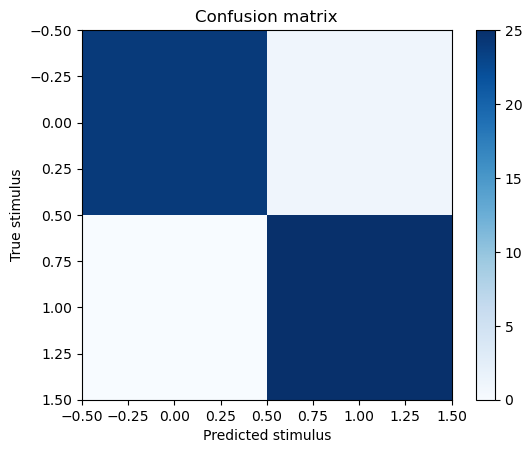

In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.imshow(cm, cmap="Blues")
plt.xlabel("Predicted stimulus")
plt.ylabel("True stimulus")
plt.title("Confusion matrix")
plt.colorbar()
plt.show()

## Cross-validation

In [7]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    decoder,
    X,
    y,
    cv=20
)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Cross-validation scores: [1.  1.  1.  1.  0.9 1.  0.9 1.  1.  1.  1.  1.  1.  1.  1.  0.9 1.  1.
 1.  1. ]
Mean accuracy: 0.985
Standard deviation: 0.03570714214271424


### Regression

In [8]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

rng = np.random.default_rng(42)

n_trials = 200
n_neurons = 40

X = rng.normal(5, 1, size=(n_trials, n_neurons))

reaction_time = (
    500
    - 10 * X[:, 0]
    - 8 * X[:, 1]
    + 5 * X[:, 2]
    + rng.normal(0, 20, size=n_trials)
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    reaction_time,
    test_size=0.25,
    random_state=42
)

regressor = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R^2:", r2)
print("MSE:", mse)

R^2: 0.09632395035984931
MSE: 533.8552220719769


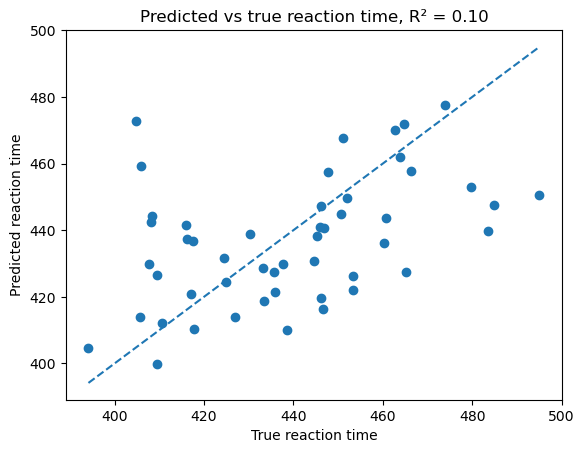

In [22]:
plt.scatter(y_test, y_pred)
plt.xlabel("True reaction time")
plt.ylabel("Predicted reaction time")
plt.title(f"Predicted vs true reaction time, R² = {r2:.2f}")

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())

plt.plot([low, high], [low, high], "--")
plt.show()

## PCA

In [9]:
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)

n_trials = 300
n_neurons = 80

z1 = rng.normal(0, 1, size=n_trials)
z2 = rng.normal(0, 1, size=n_trials)

w1 = rng.normal(0, 1, size=n_neurons)
w2 = rng.normal(0, 1, size=n_neurons)

X = (
    np.outer(z1, w1)
    + np.outer(z2, w2)
    + rng.normal(0, 0.5, size=(n_trials, n_neurons))
)

pca_pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=3)
)

Z = pca_pipeline.fit_transform(X)

print("Original shape:", X.shape)
print("Reduced shape:", Z.shape)

Original shape: (300, 80)
Reduced shape: (300, 3)


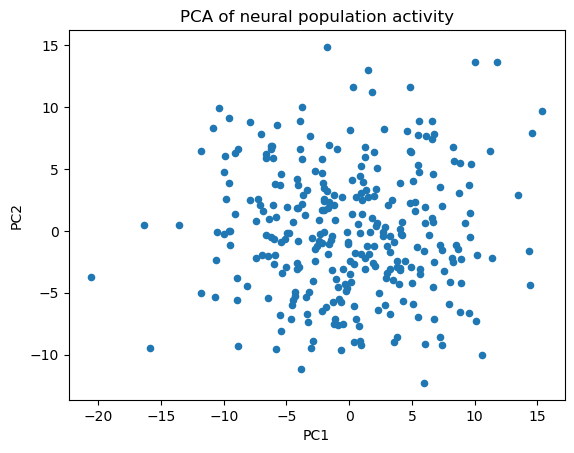

In [10]:
plt.scatter(Z[:, 0], Z[:, 1], s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of neural population activity")
plt.show()

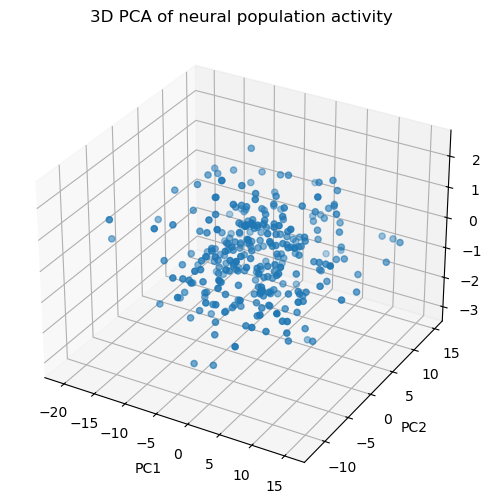

In [26]:
fig = plt.figure(figsize=(7, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    Z[:, 0],
    Z[:, 1],
    Z[:, 2],
    s=20
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA of neural population activity")

plt.show()

### k-means clustering

In [11]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)

n_neurons = 90
n_features = 20

group_1 = rng.normal(0, 0.5, size=(30, n_features))
group_2 = rng.normal(2, 0.5, size=(30, n_features))
group_3 = rng.normal(-2, 0.5, size=(30, n_features))

X_neurons = np.vstack([group_1, group_2, group_3])

kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")

labels = kmeans.fit_predict(X_neurons)

print(labels)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


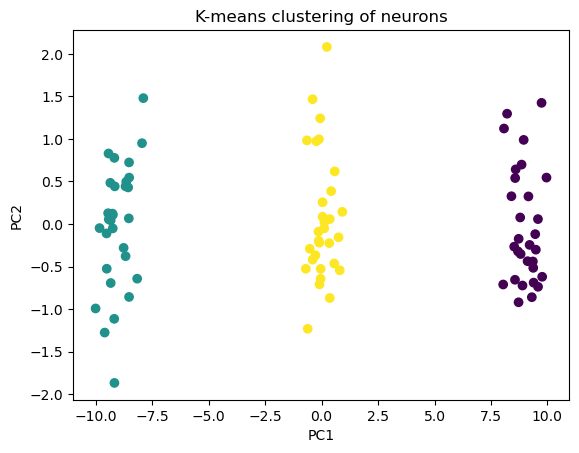

In [12]:
Z = PCA(n_components=2).fit_transform(X_neurons)

plt.scatter(Z[:, 0], Z[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means clustering of neurons")
plt.show()